In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("bank-full.csv", sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
df.shape

(45211, 17)

In [5]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [6]:
print("Missing values: ")
print(df.isnull().sum())

Missing values: 
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [7]:
print("Number of duplicate rows:")
print(df.duplicated().sum())

Number of duplicate rows:
0


In [8]:
print("Data types of each column:")
print(df.dtypes)

Data types of each column:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object


In [9]:
print("Unique values in 'y':")
print(df["y"].unique())

Unique values in 'y':
['no' 'yes']


In [10]:
print("Marketing campaign outcome:")
print(df["y"].value_counts())

Marketing campaign outcome:
y
no     39922
yes     5289
Name: count, dtype: int64


In [11]:
print("\nMarketing campaign outcome in percentage:")
print(df["y"].value_counts(normalize=True) * 100)


Marketing campaign outcome in percentage:
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


In [12]:
print("Contact methods:")
print(df["contact"].value_counts())

Contact methods:
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64


In [13]:
print("Number of contacts during the current campaign:")
print(df["campaign"].value_counts().sort_index())

Number of contacts during the current campaign:
campaign
1     17544
2     12505
3      5521
4      3522
5      1764
6      1291
7       735
8       540
9       327
10      266
11      201
12      155
13      133
14       93
15       84
16       79
17       69
18       51
19       44
20       43
21       35
22       23
23       22
24       20
25       22
26       13
27       10
28       16
29       16
30        8
31       12
32        9
33        6
34        5
35        4
36        4
37        2
38        3
39        1
41        2
43        3
44        1
46        1
50        2
51        1
55        1
58        1
63        1
Name: count, dtype: int64


In [14]:
print("Previous campaign outcome:")
print(df["poutcome"].value_counts())

Previous campaign outcome:
poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64


In [15]:
print("Campaign months:")
print(df["month"].value_counts())

Campaign months:
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64


In [16]:
print("Job categories:")
print(df["job"].value_counts())

Job categories:
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64


In [17]:
print("Summary statistics for numerical columns:")
print(df.describe())

Summary statistics for numerical columns:
                age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              pdays      previous  
count  45211.000000  45211.000000  
mean      40.197828      0.580323  
std      100.128746      2.303441  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000  

In [18]:
print("Minimum values:")
print(df[["age", "balance", "duration", "campaign", "pdays", "previous"]].min())

print("\nMaximum values:")
print(df[["age", "balance", "duration", "campaign", "pdays", "previous"]].max())

Minimum values:
age           18
balance    -8019
duration       0
campaign       1
pdays         -1
previous       0
dtype: int64

Maximum values:
age             95
balance     102127
duration      4918
campaign        63
pdays          871
previous       275
dtype: int64


In [19]:
print("Customers not previously contacted:")
print((df["pdays"] == -1).sum())

print("\nPercentage of customers not previously contacted:")
print((df["pdays"] == -1).mean() * 100)

Customers not previously contacted:
36954

Percentage of customers not previously contacted:
81.73674548229414


In [20]:
print("Customers with no previous contact and unknown previous outcome:")
print(((df["pdays"] == -1) & (df["poutcome"] == "unknown")).sum())

Customers with no previous contact and unknown previous outcome:
36954


In [21]:
categorical_columns = df.select_dtypes(include="object").columns

print("Unique values in categorical columns:\n")

for column in categorical_columns:
    print(f"{column}:")
    print(df[column].unique())
    print()

Unique values in categorical columns:

job:
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']

marital:
['married' 'single' 'divorced']

education:
['tertiary' 'secondary' 'unknown' 'primary']

default:
['no' 'yes']

housing:
['yes' 'no']

loan:
['no' 'yes']

contact:
['unknown' 'cellular' 'telephone']

month:
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

poutcome:
['unknown' 'failure' 'other' 'success']

y:
['no' 'yes']



In [22]:
total_customers = len(df)
successful_conversions = (df["y"] == "yes").sum()

conversion_rate = (successful_conversions / total_customers) * 100

print("Total customers contacted:", total_customers)
print("Successful conversions:", successful_conversions)
print("Overall conversion rate:", round(conversion_rate, 2), "%")

Total customers contacted: 45211
Successful conversions: 5289
Overall conversion rate: 11.7 %


In [23]:
contact_analysis = df.groupby("contact")["y"].agg(
    total_customers="count",
    successful_conversions=lambda x: (x == "yes").sum()
)

contact_analysis["conversion_rate"] = (
    contact_analysis["successful_conversions"]
    / contact_analysis["total_customers"]
) * 100

print("Conversion analysis by contact method:")
print(contact_analysis.round(2))

Conversion analysis by contact method:
           total_customers  successful_conversions  conversion_rate
contact                                                            
cellular             29285                    4369            14.92
telephone             2906                     390            13.42
unknown              13020                     530             4.07


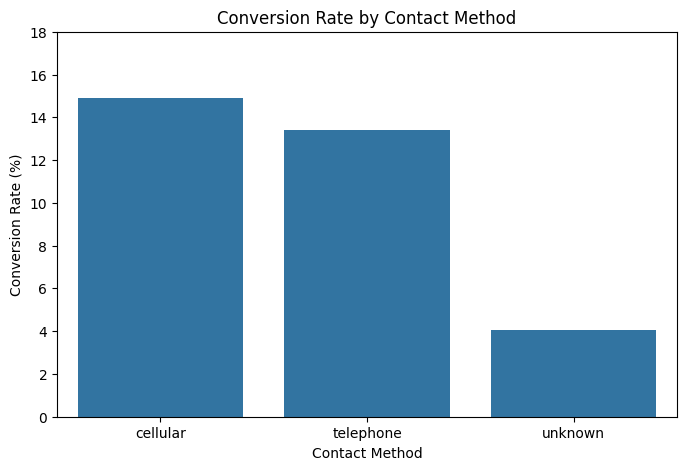

In [24]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=contact_analysis.index,
    y=contact_analysis["conversion_rate"]
)

plt.title("Conversion Rate by Contact Method")
plt.xlabel("Contact Method")
plt.ylabel("Conversion Rate (%)")
plt.ylim(0, 18)

plt.show()

In [25]:
previous_analysis = df.groupby("poutcome")["y"].agg(
    total_customers="count",
    successful_conversions=lambda x: (x == "yes").sum()
)

previous_analysis["conversion_rate"] = (
    previous_analysis["successful_conversions"]
    / previous_analysis["total_customers"]
) * 100

print("Conversion analysis by previous campaign outcome:")
print(previous_analysis.round(2))

Conversion analysis by previous campaign outcome:
          total_customers  successful_conversions  conversion_rate
poutcome                                                          
failure              4901                     618            12.61
other                1840                     307            16.68
success              1511                     978            64.73
unknown             36959                    3386             9.16


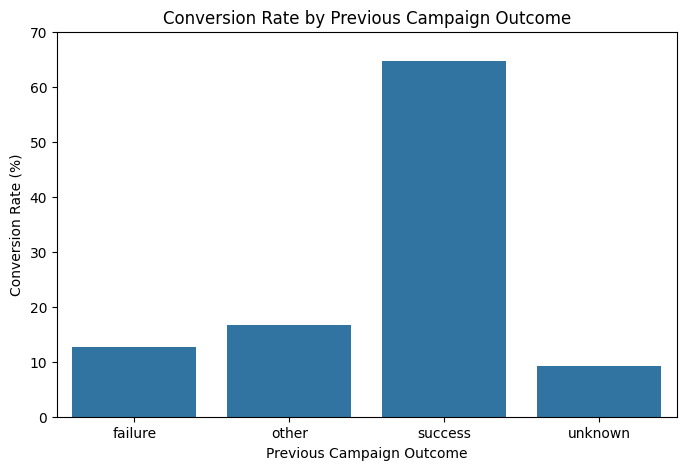

In [26]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=previous_analysis.index,
    y=previous_analysis["conversion_rate"]
)

plt.title("Conversion Rate by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Conversion Rate (%)")
plt.ylim(0, 70)

plt.show()

In [27]:
campaign_analysis = df.groupby("campaign")["y"].agg(
    total_customers="count",
    successful_conversions=lambda x: (x == "yes").sum()
)

campaign_analysis["conversion_rate"] = (
    campaign_analysis["successful_conversions"]
    / campaign_analysis["total_customers"]
) * 100

print("Conversion analysis by number of campaign contacts:")
print(campaign_analysis.round(2))

Conversion analysis by number of campaign contacts:
          total_customers  successful_conversions  conversion_rate
campaign                                                          
1                   17544                    2561            14.60
2                   12505                    1401            11.20
3                    5521                     618            11.19
4                    3522                     317             9.00
5                    1764                     139             7.88
6                    1291                      92             7.13
7                     735                      47             6.39
8                     540                      32             5.93
9                     327                      21             6.42
10                    266                      14             5.26
11                    201                      16             7.96
12                    155                       4             2.58
13        

In [28]:
# Create campaign contact groups
def contact_group(value):
    if value == 1:
        return "1 contact"
    elif value <= 3:
        return "2-3 contacts"
    elif value <= 5:
        return "4-5 contacts"
    elif value <= 10:
        return "6-10 contacts"
    else:
        return "11+ contacts"


df["campaign_group"] = df["campaign"].apply(contact_group)

print("Campaign contact groups:")
print(df["campaign_group"].value_counts())

Campaign contact groups:
campaign_group
2-3 contacts     18026
1 contact        17544
4-5 contacts      5286
6-10 contacts     3159
11+ contacts      1196
Name: count, dtype: int64


In [29]:
campaign_group_analysis = df.groupby("campaign_group")["y"].agg(
    total_customers="count",
    successful_conversions=lambda x: (x == "yes").sum()
)

campaign_group_analysis["conversion_rate"] = (
    campaign_group_analysis["successful_conversions"]
    / campaign_group_analysis["total_customers"]
) * 100

print("Conversion analysis by campaign contact group:")
print(campaign_group_analysis.round(2))

Conversion analysis by campaign contact group:
                total_customers  successful_conversions  conversion_rate
campaign_group                                                          
1 contact                 17544                    2561            14.60
11+ contacts               1196                      47             3.93
2-3 contacts              18026                    2019            11.20
4-5 contacts               5286                     456             8.63
6-10 contacts              3159                     206             6.52


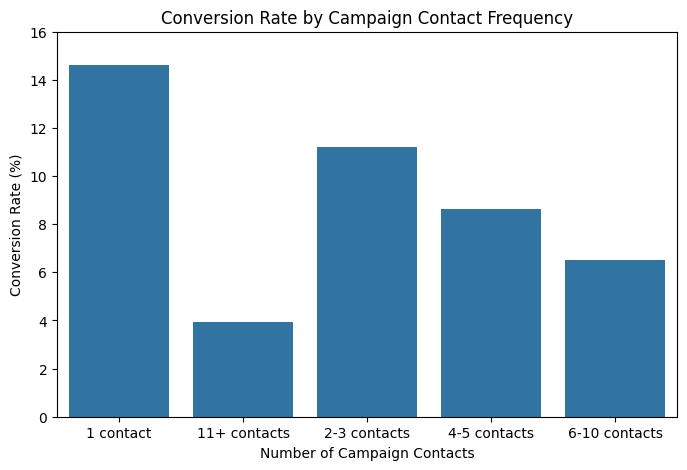

In [30]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=campaign_group_analysis.index,
    y=campaign_group_analysis["conversion_rate"]
)

plt.title("Conversion Rate by Campaign Contact Frequency")
plt.xlabel("Number of Campaign Contacts")
plt.ylabel("Conversion Rate (%)")
plt.ylim(0, 16)

plt.show()

In [31]:
month_analysis = df.groupby("month")["y"].agg(
    total_customers="count",
    successful_conversions=lambda x: (x == "yes").sum()
)

month_analysis["conversion_rate"] = (
    month_analysis["successful_conversions"]
    / month_analysis["total_customers"]
) * 100

# Arrange months in calendar order
month_order = [
    "jan", "feb", "mar", "apr", "may", "jun",
    "jul", "aug", "sep", "oct", "nov", "dec"
]

month_analysis = month_analysis.reindex(month_order)

print("Conversion analysis by month:")
print(month_analysis.round(2))

Conversion analysis by month:
       total_customers  successful_conversions  conversion_rate
month                                                          
jan               1403                     142            10.12
feb               2649                     441            16.65
mar                477                     248            51.99
apr               2932                     577            19.68
may              13766                     925             6.72
jun               5341                     546            10.22
jul               6895                     627             9.09
aug               6247                     688            11.01
sep                579                     269            46.46
oct                738                     323            43.77
nov               3970                     403            10.15
dec                214                     100            46.73


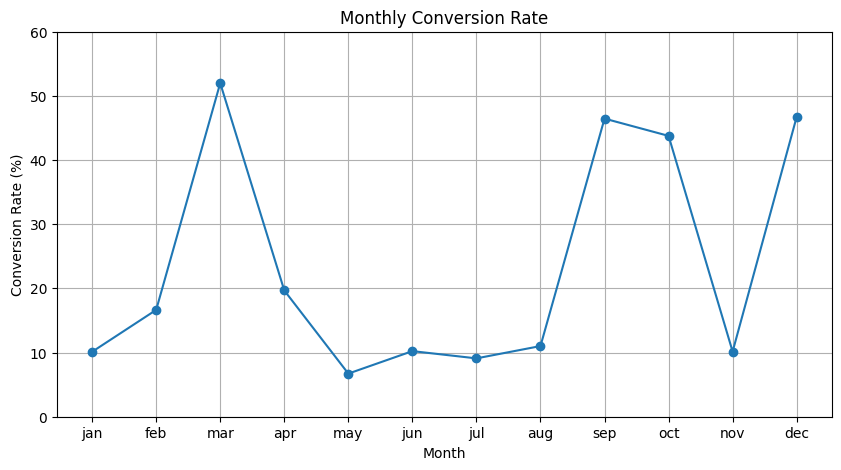

In [32]:
plt.figure(figsize=(10, 5))

plt.plot(
    month_analysis.index,
    month_analysis["conversion_rate"],
    marker="o"
)

plt.title("Monthly Conversion Rate")
plt.xlabel("Month")
plt.ylabel("Conversion Rate (%)")
plt.ylim(0, 60)
plt.grid(True)

plt.show()

In [33]:
# Create age groups
def age_group(age):
    if age <= 25:
        return "18-25"
    elif age <= 35:
        return "26-35"
    elif age <= 45:
        return "36-45"
    elif age <= 55:
        return "46-55"
    elif age <= 65:
        return "56-65"
    else:
        return "66+"


df["age_group"] = df["age"].apply(age_group)

print("Customer distribution by age group:")
print(df["age_group"].value_counts().sort_index())

Customer distribution by age group:
age_group
18-25     1336
26-35    15571
36-45    13856
46-55     9548
56-65     4149
66+        751
Name: count, dtype: int64


In [34]:
age_analysis = df.groupby("age_group")["y"].agg(
    total_customers="count",
    successful_conversions=lambda x: (x == "yes").sum()
)

age_analysis["conversion_rate"] = (
    age_analysis["successful_conversions"]
    / age_analysis["total_customers"]
) * 100

print("Conversion analysis by age group:")
print(age_analysis.round(2))

Conversion analysis by age group:
           total_customers  successful_conversions  conversion_rate
age_group                                                          
18-25                 1336                     320            23.95
26-35                15571                    1869            12.00
36-45                13856                    1301             9.39
46-55                 9548                     893             9.35
56-65                 4149                     586            14.12
66+                    751                     320            42.61


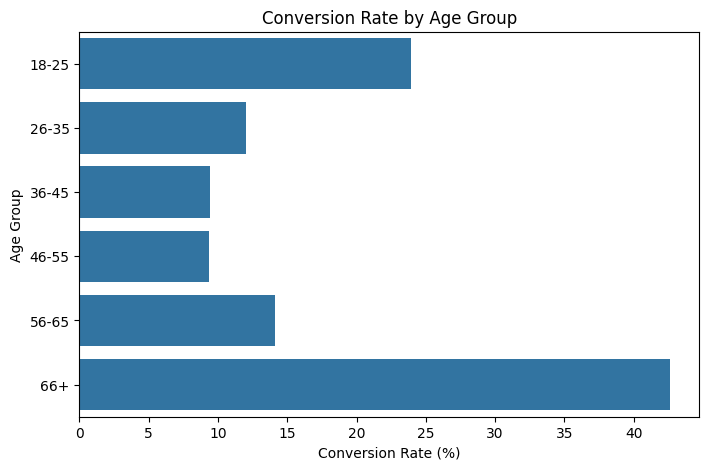

In [35]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=age_analysis["conversion_rate"],
    y=age_analysis.index
)

plt.title("Conversion Rate by Age Group")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("Age Group")

plt.show()

In [36]:
job_analysis = df.groupby("job")["y"].agg(
    total_customers="count",
    successful_conversions=lambda x: (x == "yes").sum()
)

job_analysis["conversion_rate"] = (
    job_analysis["successful_conversions"]
    / job_analysis["total_customers"]
) * 100

print("Conversion analysis by job category:")
print(job_analysis.sort_values("conversion_rate", ascending=False).round(2))

Conversion analysis by job category:
               total_customers  successful_conversions  conversion_rate
job                                                                    
student                    938                     269            28.68
retired                   2264                     516            22.79
unemployed                1303                     202            15.50
management                9458                    1301            13.76
admin.                    5171                     631            12.20
self-employed             1579                     187            11.84
unknown                    288                      34            11.81
technician                7597                     840            11.06
services                  4154                     369             8.88
housemaid                 1240                     109             8.79
entrepreneur              1487                     123             8.27
blue-collar               9

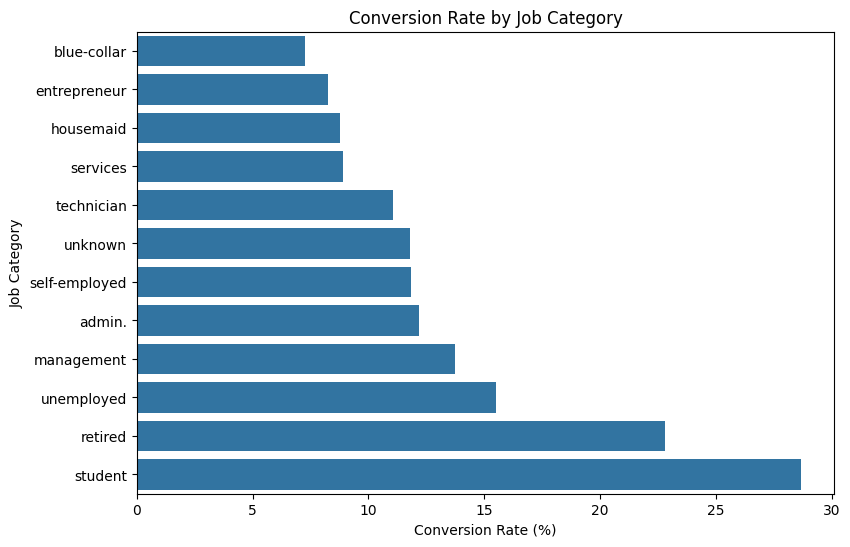

In [37]:
plt.figure(figsize=(9, 6))

job_plot = job_analysis.sort_values("conversion_rate")

sns.barplot(
    x=job_plot["conversion_rate"],
    y=job_plot.index
)

plt.title("Conversion Rate by Job Category")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("Job Category")

plt.show()

In [38]:
education_analysis = df.groupby("education")["y"].agg(
    total_customers="count",
    successful_conversions=lambda x: (x == "yes").sum()
)

education_analysis["conversion_rate"] = (
    education_analysis["successful_conversions"]
    / education_analysis["total_customers"]
) * 100

print("Conversion analysis by education level:")
print(education_analysis.round(2))

Conversion analysis by education level:
           total_customers  successful_conversions  conversion_rate
education                                                          
primary               6851                     591             8.63
secondary            23202                    2450            10.56
tertiary             13301                    1996            15.01
unknown               1857                     252            13.57


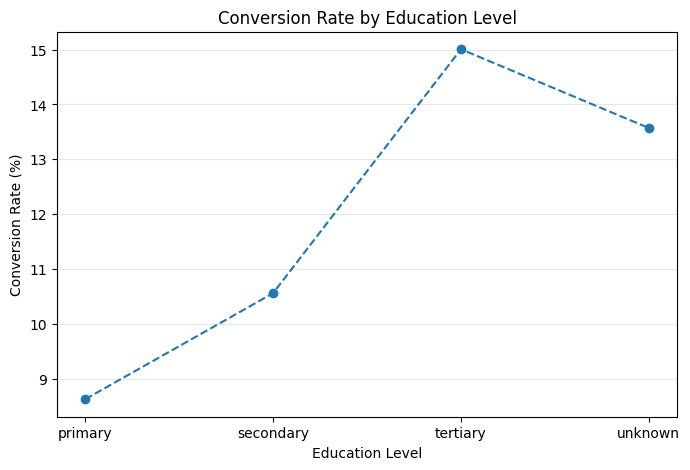

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(
    education_analysis.index,
    education_analysis["conversion_rate"],
    marker="o",
    linestyle="--"
)

plt.title("Conversion Rate by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Conversion Rate (%)")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [40]:
housing_analysis = df.groupby("housing")["y"].agg(
    total_customers="count",
    successful_conversions=lambda x: (x == "yes").sum()
)

housing_analysis["conversion_rate"] = (
    housing_analysis["successful_conversions"]
    / housing_analysis["total_customers"]
) * 100

print("Conversion analysis by housing loan status:")
print(housing_analysis.round(2))

Conversion analysis by housing loan status:
         total_customers  successful_conversions  conversion_rate
housing                                                          
no                 20081                    3354             16.7
yes                25130                    1935              7.7


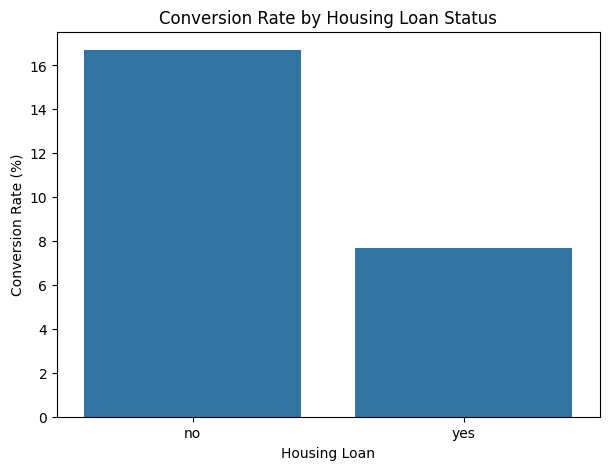

In [43]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=housing_analysis.index,
    y=housing_analysis["conversion_rate"]
)

plt.title("Conversion Rate by Housing Loan Status")
plt.xlabel("Housing Loan")
plt.ylabel("Conversion Rate (%)")

plt.show()

In [44]:
loan_analysis = df.groupby("loan")["y"].agg(
    total_customers="count",
    successful_conversions=lambda x: (x == "yes").sum()
)

loan_analysis["conversion_rate"] = (
    loan_analysis["successful_conversions"]
    / loan_analysis["total_customers"]
) * 100

print("Conversion analysis by personal loan status:")
print(loan_analysis.round(2))

Conversion analysis by personal loan status:
      total_customers  successful_conversions  conversion_rate
loan                                                          
no              37967                    4805            12.66
yes              7244                     484             6.68


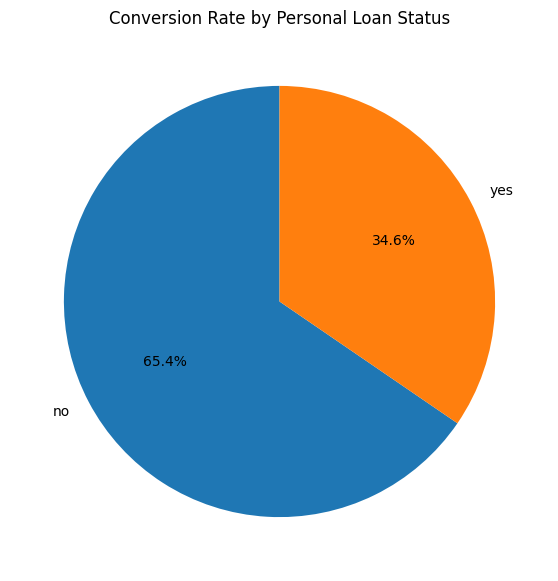

In [46]:
plt.figure(figsize=(7, 7))

plt.pie(
    loan_analysis["conversion_rate"],
    labels=loan_analysis.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Conversion Rate by Personal Loan Status")

plt.show()

In [47]:
marital_analysis = df.groupby("marital")["y"].agg(
    total_customers="count",
    successful_conversions=lambda x: (x == "yes").sum()
)

marital_analysis["conversion_rate"] = (
    marital_analysis["successful_conversions"]
    / marital_analysis["total_customers"]
) * 100

print("Conversion analysis by marital status:")
print(marital_analysis.round(2))

Conversion analysis by marital status:
          total_customers  successful_conversions  conversion_rate
marital                                                           
divorced             5207                     622            11.95
married             27214                    2755            10.12
single              12790                    1912            14.95


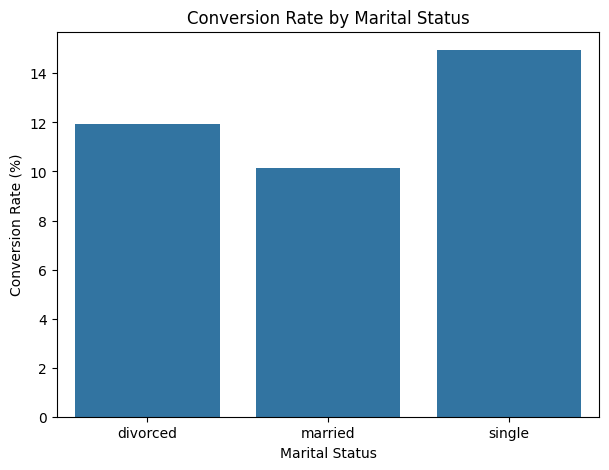

In [49]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=marital_analysis.index,
    y=marital_analysis["conversion_rate"]
)

plt.title("Conversion Rate by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Conversion Rate (%)")

plt.show()

In [50]:
default_analysis = df.groupby("default")["y"].agg(
    total_customers="count",
    successful_conversions=lambda x: (x == "yes").sum()
)

default_analysis["conversion_rate"] = (
    default_analysis["successful_conversions"]
    / default_analysis["total_customers"]
) * 100

print("Conversion analysis by default status:")
print(default_analysis.round(2))

Conversion analysis by default status:
         total_customers  successful_conversions  conversion_rate
default                                                          
no                 44396                    5237            11.80
yes                  815                      52             6.38


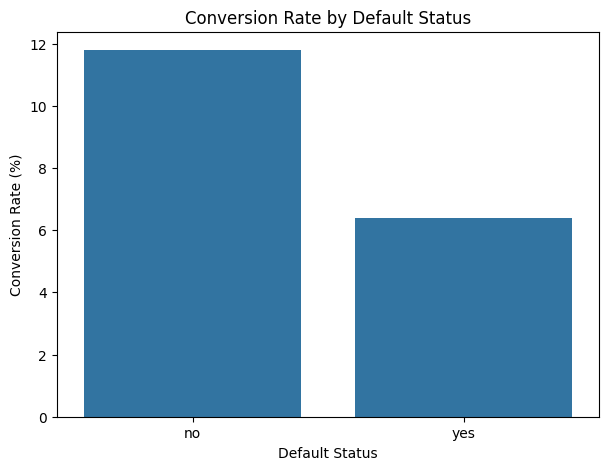

In [51]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=default_analysis.index,
    y=default_analysis["conversion_rate"]
)

plt.title("Conversion Rate by Default Status")
plt.xlabel("Default Status")
plt.ylabel("Conversion Rate (%)")

plt.show()

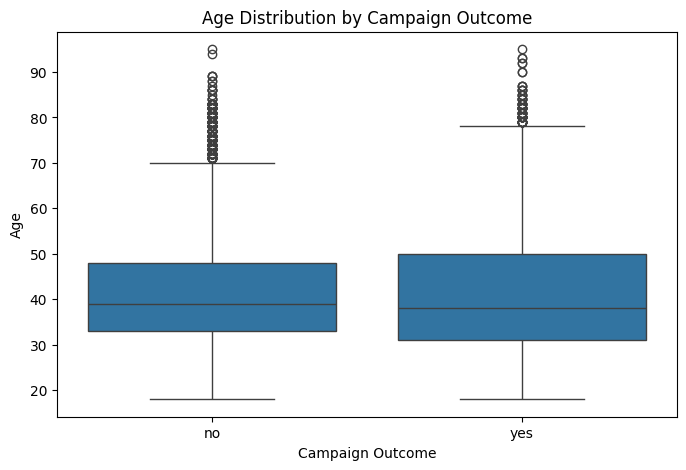

In [52]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="y",
    y="age",
    data=df
)

plt.title("Age Distribution by Campaign Outcome")
plt.xlabel("Campaign Outcome")
plt.ylabel("Age")

plt.show()

In [54]:
balance_analysis = df.groupby("y")["balance"].mean()

print("Average balance by campaign outcome:")
print(balance_analysis.round(2))

Average balance by campaign outcome:
y
no     1303.71
yes    1804.27
Name: balance, dtype: float64


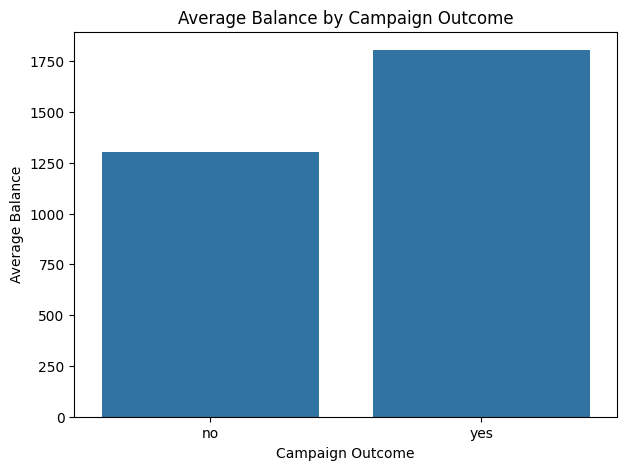

In [55]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=balance_analysis.index,
    y=balance_analysis.values
)

plt.title("Average Balance by Campaign Outcome")
plt.xlabel("Campaign Outcome")
plt.ylabel("Average Balance")

plt.show()

In [56]:
duration_analysis = df.groupby("y")["duration"].mean()

print("Average contact duration by campaign outcome:")
print(duration_analysis.round(2))

Average contact duration by campaign outcome:
y
no     221.18
yes    537.29
Name: duration, dtype: float64


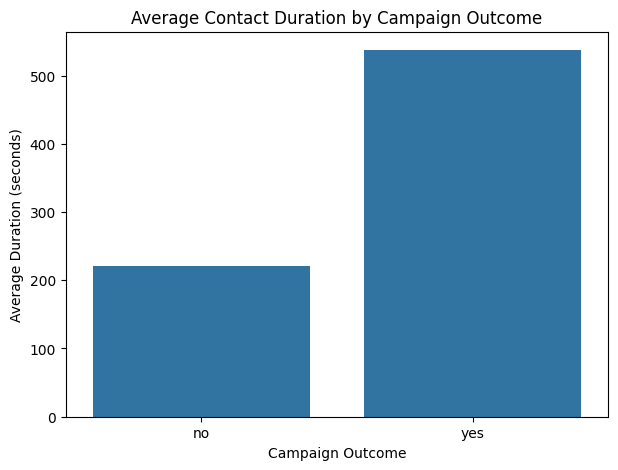

In [57]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=duration_analysis.index,
    y=duration_analysis.values
)

plt.title("Average Contact Duration by Campaign Outcome")
plt.xlabel("Campaign Outcome")
plt.ylabel("Average Duration (seconds)")

plt.show()

In [58]:
previous_analysis_num = df.groupby("y")["previous"].mean()

print("Average number of previous contacts by campaign outcome:")
print(previous_analysis_num.round(2))

Average number of previous contacts by campaign outcome:
y
no     0.50
yes    1.17
Name: previous, dtype: float64


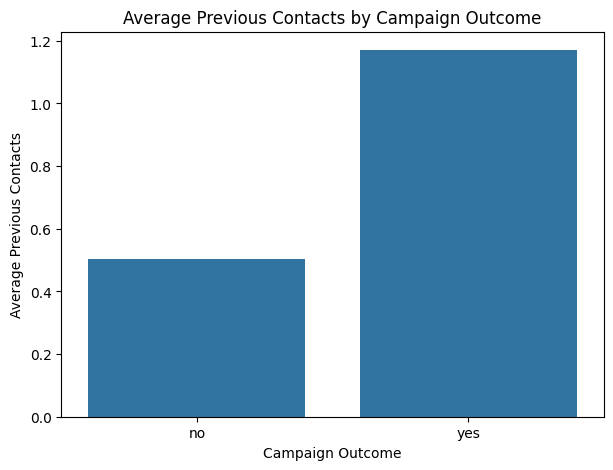

In [59]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=previous_analysis_num.index,
    y=previous_analysis_num.values
)

plt.title("Average Previous Contacts by Campaign Outcome")
plt.xlabel("Campaign Outcome")
plt.ylabel("Average Previous Contacts")

plt.show()

In [60]:
age_outcome_analysis = df.groupby("y")["age"].mean()

print("Average age by campaign outcome:")
print(age_outcome_analysis.round(2))

Average age by campaign outcome:
y
no     40.84
yes    41.67
Name: age, dtype: float64


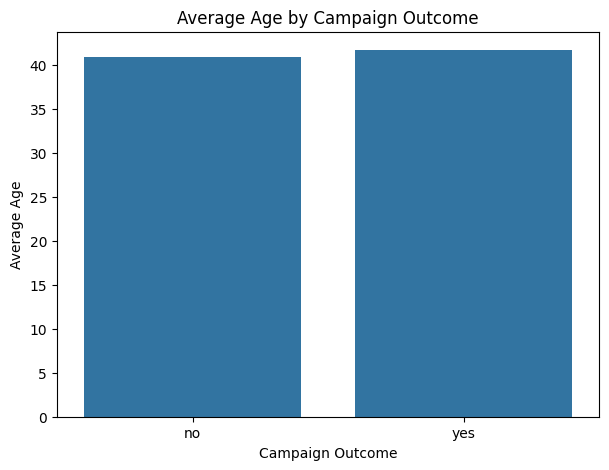

In [61]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=age_outcome_analysis.index,
    y=age_outcome_analysis.values
)

plt.title("Average Age by Campaign Outcome")
plt.xlabel("Campaign Outcome")
plt.ylabel("Average Age")

plt.show()

In [62]:
# Select numerical columns
numeric_columns = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

correlation_matrix = df[numeric_columns].corr()

print("Correlation matrix:")
print(correlation_matrix.round(2))

Correlation matrix:
           age  balance   day  duration  campaign  pdays  previous
age       1.00     0.10 -0.01     -0.00      0.00  -0.02      0.00
balance   0.10     1.00  0.00      0.02     -0.01   0.00      0.02
day      -0.01     0.00  1.00     -0.03      0.16  -0.09     -0.05
duration -0.00     0.02 -0.03      1.00     -0.08  -0.00      0.00
campaign  0.00    -0.01  0.16     -0.08      1.00  -0.09     -0.03
pdays    -0.02     0.00 -0.09     -0.00     -0.09   1.00      0.45
previous  0.00     0.02 -0.05      0.00     -0.03   0.45      1.00


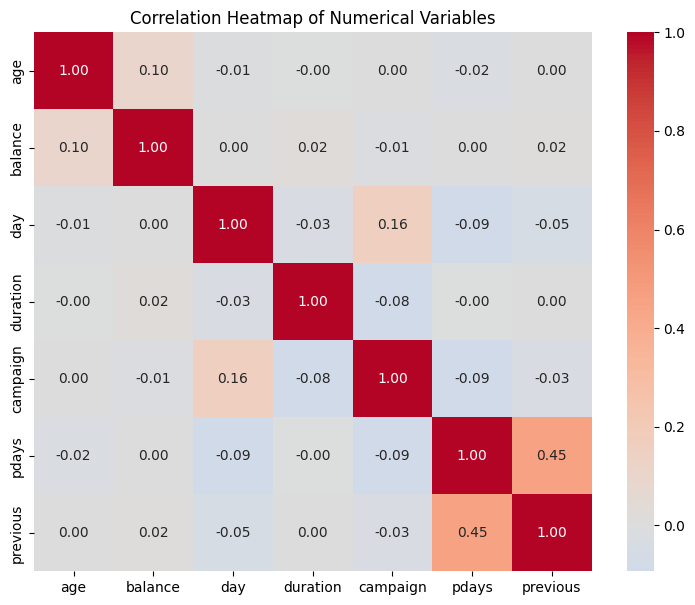

In [63]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.show()

In [64]:
print("========== TASK 3 CAMPAIGN SUMMARY ==========")

print("Total customers contacted:", len(df))

successful = (df["y"] == "yes").sum()
print("Successful conversions:", successful)

conversion_rate = (successful / len(df)) * 100
print("Overall conversion rate:", round(conversion_rate, 2), "%")

print("\nBest observed conversion by contact method:")
print(contact_analysis["conversion_rate"].idxmax(),
      "->", round(contact_analysis["conversion_rate"].max(), 2), "%")

print("\nBest observed conversion by previous campaign outcome:")
print(previous_analysis["conversion_rate"].idxmax(),
      "->", round(previous_analysis["conversion_rate"].max(), 2), "%")

print("\nBest observed conversion by age group:")
print(age_analysis["conversion_rate"].idxmax(),
      "->", round(age_analysis["conversion_rate"].max(), 2), "%")

print("\nBest observed conversion by job category:")
print(job_analysis["conversion_rate"].idxmax(),
      "->", round(job_analysis["conversion_rate"].max(), 2), "%")

========== TASK 3 CAMPAIGN SUMMARY ==========
Total customers contacted: 45211
Successful conversions: 5289
Overall conversion rate: 11.7 %

Best observed conversion by contact method:
cellular -> 14.92 %

Best observed conversion by previous campaign outcome:
success -> 64.73 %

Best observed conversion by age group:
66+ -> 42.61 %

Best observed conversion by job category:
student -> 28.68 %


In [65]:
# Funnel stages
total_contacted = len(df)
successful_conversions = (df["y"] == "yes").sum()
unsuccessful = (df["y"] == "no").sum()

print("========== FUNNEL ANALYSIS ==========")

print("Stage 1 - Customers contacted:", total_contacted)
print("Stage 2 - Successful conversions:", successful_conversions)

print("\nDrop-off:")
print("Customers who did not convert:", unsuccessful)

print("\nLead-to-customer conversion rate:",
      round((successful_conversions / total_contacted) * 100, 2), "%")

print("Lead-to-customer drop-off rate:",
      round((unsuccessful / total_contacted) * 100, 2), "%")

========== FUNNEL ANALYSIS ==========
Stage 1 - Customers contacted: 45211
Stage 2 - Successful conversions: 5289

Drop-off:
Customers who did not convert: 39922

Lead-to-customer conversion rate: 11.7 %
Lead-to-customer drop-off rate: 88.3 %


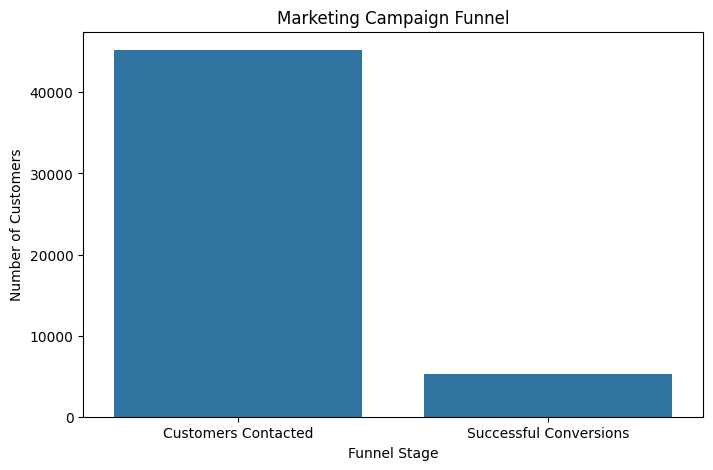

In [66]:
funnel_stages = ["Customers Contacted", "Successful Conversions"]
funnel_values = [total_contacted, successful_conversions]

plt.figure(figsize=(8, 5))

sns.barplot(
    x=funnel_stages,
    y=funnel_values
)

plt.title("Marketing Campaign Funnel")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Customers")

plt.show()

# Key Findings

- The dataset contains **45,211 customer records**, of which **5,289 customers converted**, giving an overall conversion rate of **11.70%**.
- The campaign had an **88.30% observed drop-off**, as 39,922 contacted customers did not convert.
- Among contact methods, **cellular** had the highest observed conversion rate at **14.92%**.
- Customers with a previous campaign outcome of **success** had an observed conversion rate of **64.73%**.
- Conversion rates generally decreased as the number of contacts increased, from **14.60%** for customers contacted once to **3.93%** for customers contacted 11 or more times.
- Conversion rates varied across months, age groups, job categories, and education levels.
- The **66+ age group** had an observed conversion rate of **42.61%**, while the **student** job category had an observed conversion rate of **28.68%**.
- The correlation analysis showed mostly weak relationships among numerical variables. The strongest observed correlation was between `pdays` and `previous`, with a value of **0.45**.

# Recommendations

- Improve the quality and availability of customer contact information to support effective communication.
- Use previous campaign outcomes to help segment customers for future campaigns.
- Monitor contact frequency and avoid unnecessary repeated contacts.
- Consider customer characteristics such as age, job, and education when creating targeted customer segments.
- Monitor campaign performance across different months and compare conversion rates along with the number of customers contacted.
- Focus on improving the conversion process because **88.30% of contacted customers did not convert**.
- Continue monitoring campaign performance using data-driven metrics such as conversion rate, contact method, campaign frequency, and previous campaign outcome.

# Conclusion

The analysis of the marketing campaign dataset provided insights into customer conversion patterns and campaign performance. Out of 45,211 contacted customers, 5,289 successfully converted, resulting in an overall conversion rate of **11.70%**. Conversion rates varied across contact methods, previous campaign outcomes, contact frequency, months, and customer characteristics.

The analysis also showed that most numerical variables had weak linear relationships with each other, while `pdays` and `previous` showed a moderate positive correlation of **0.45**. Overall, the findings can help support more targeted customer segmentation, better campaign monitoring, and improved marketing strategies. The results represent observed associations in the dataset and should not be interpreted as proof of causation.